In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

from train import *
from utils import get_sobol_indices
from utils_plot import *

Load data and configuration

In [2]:
cohort = "hmp"

config = importlib.import_module("config")
attrs = importlib.import_module(f"{cohort}_data")
args = getattr(config, "args")

args.name = f"{args.cohort}-{args.task}-{args.method}"
args.name += f"-L{args.latent_dim}"

Train model

In [ ]:
results = train1(attrs, args)
model = results["model"]
torch.save(model, f"{args.name}.pt")

In [4]:
model = torch.load(Path(f"{args.name}.pt"), weights_only=False)

Visualization

In [5]:
plt.rcParams.update({
    "figure.figsize": [3.5, 2.625],
    "lines.linewidth": 1,
    "font.family": "serif",
    "font.size": 10,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42
})

In [6]:
model.eval()
B = model.get_beta()
L = model.latent_dim
dataset = MetagenomeDataset(attrs.y, attrs.x_num, attrs.x_cat)
X = dataset[:]["x"]
Y = dataset[:]["y"]
X_mask = dataset[:]["x_mask"]
theta = model.get_theta(X, Y, X_mask)

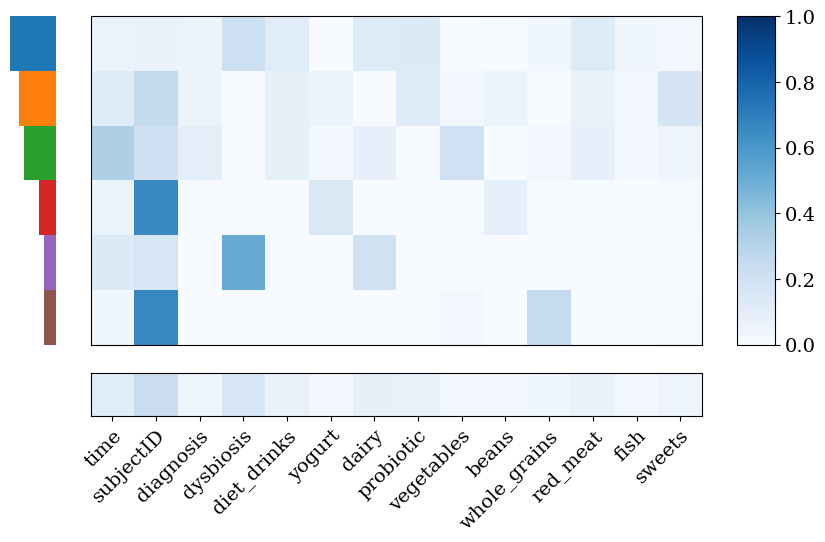

In [7]:
# compute Sobol' index and plot the heatmap
def get_theta(x):
    x = np.transpose(x)
    x = torch.Tensor(x)
    theta = model.get_theta(x)
    f_eval = np.transpose(theta)
    return f_eval

sobol_result, sobol_agg = get_sobol_indices(get_theta, dataset, attrs)

plt.rcParams.update({"font.size": 14})
fig_si, _ = plot_si_heatmap(theta, sobol_result, sobol_agg, attrs.x_cols)

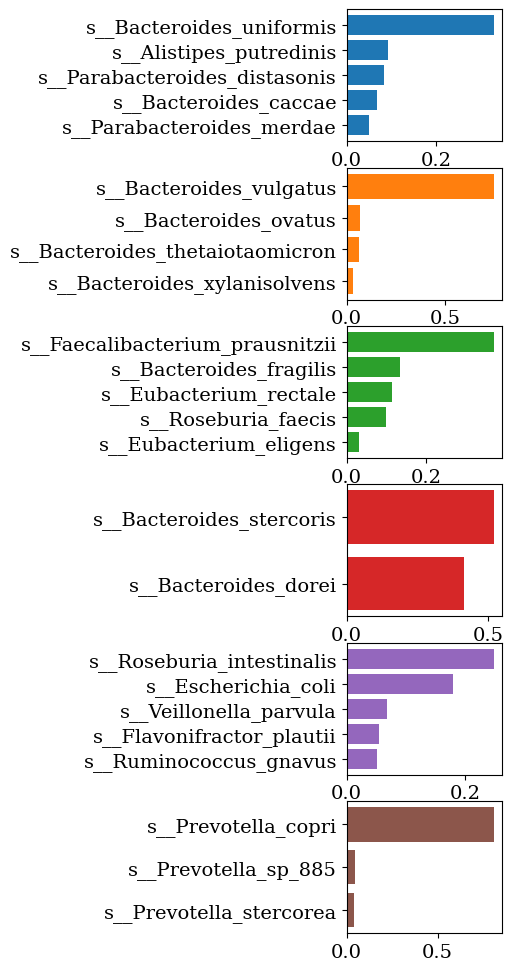

In [8]:
# plot taxonomic composition of topics
fig_topics, _, = plot_topics(B, theta, attrs.species)

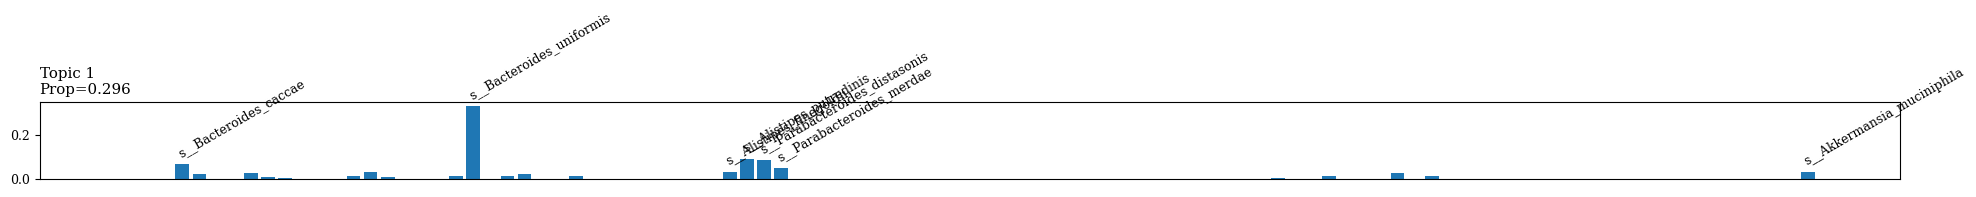

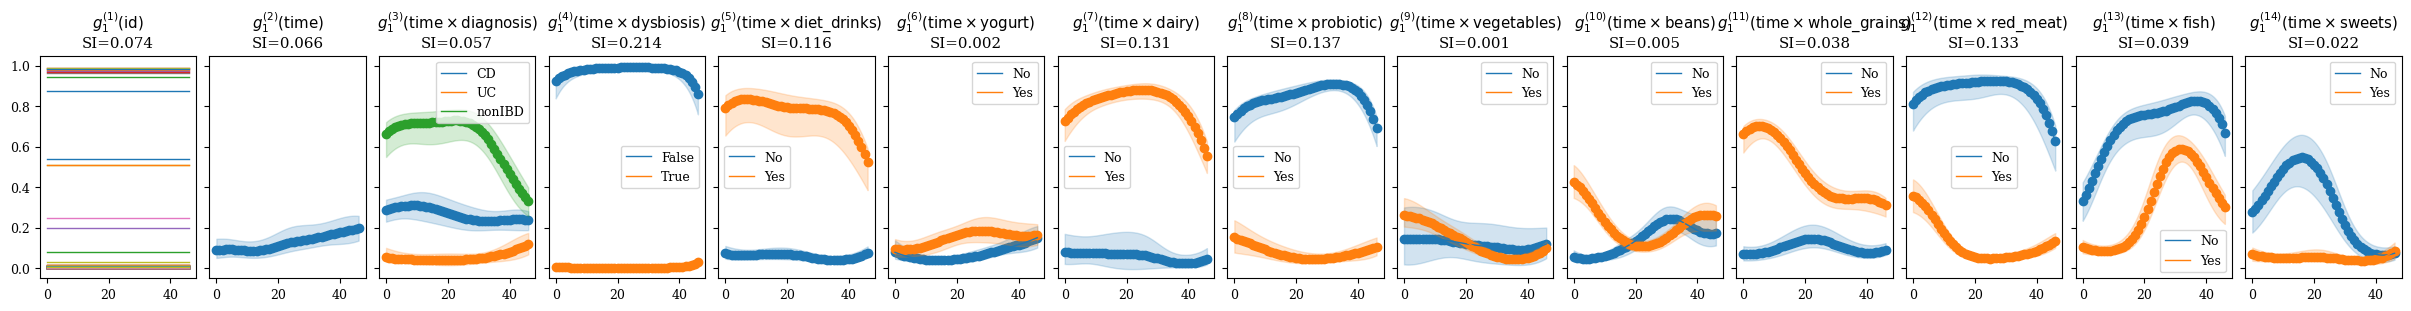

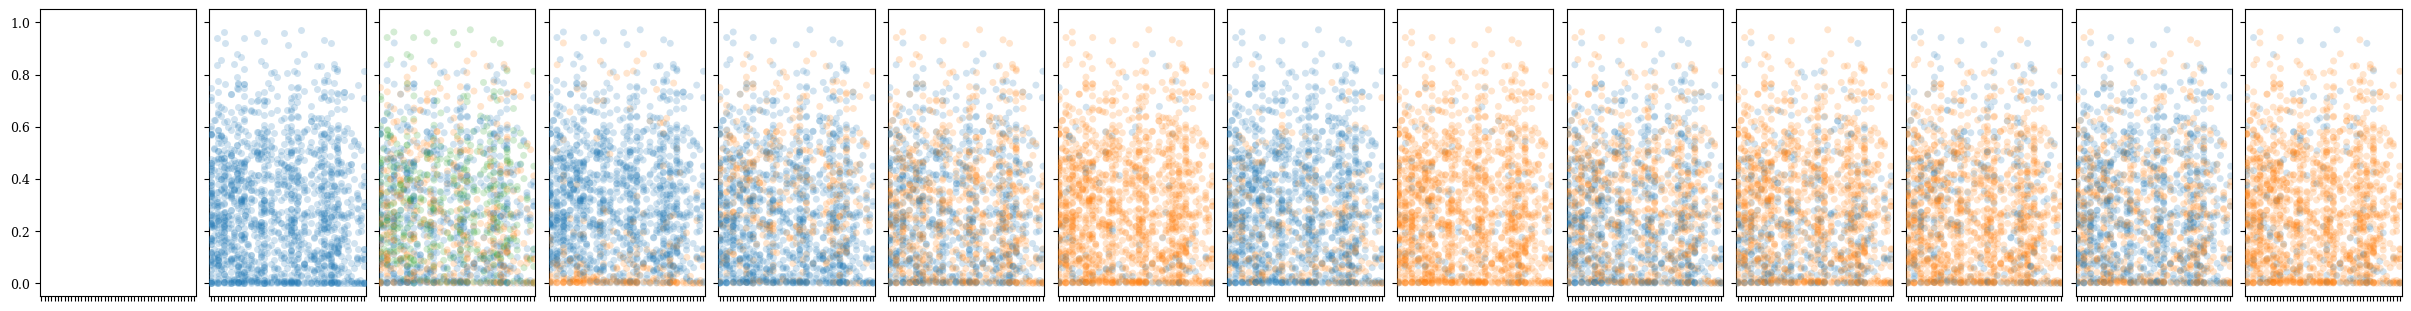

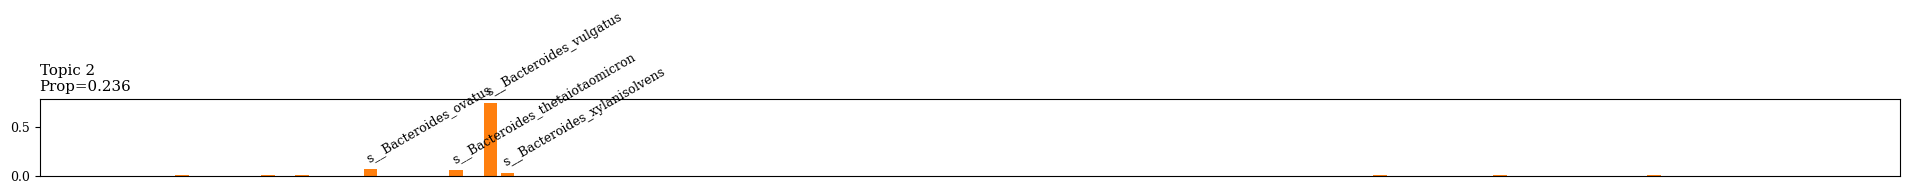

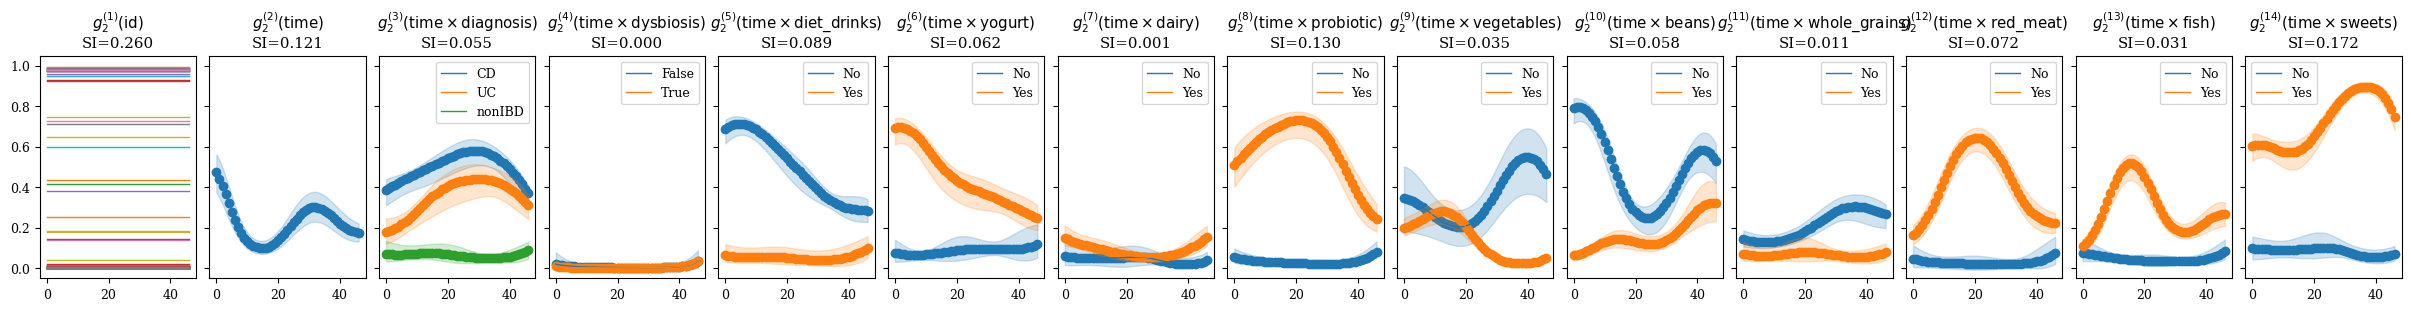

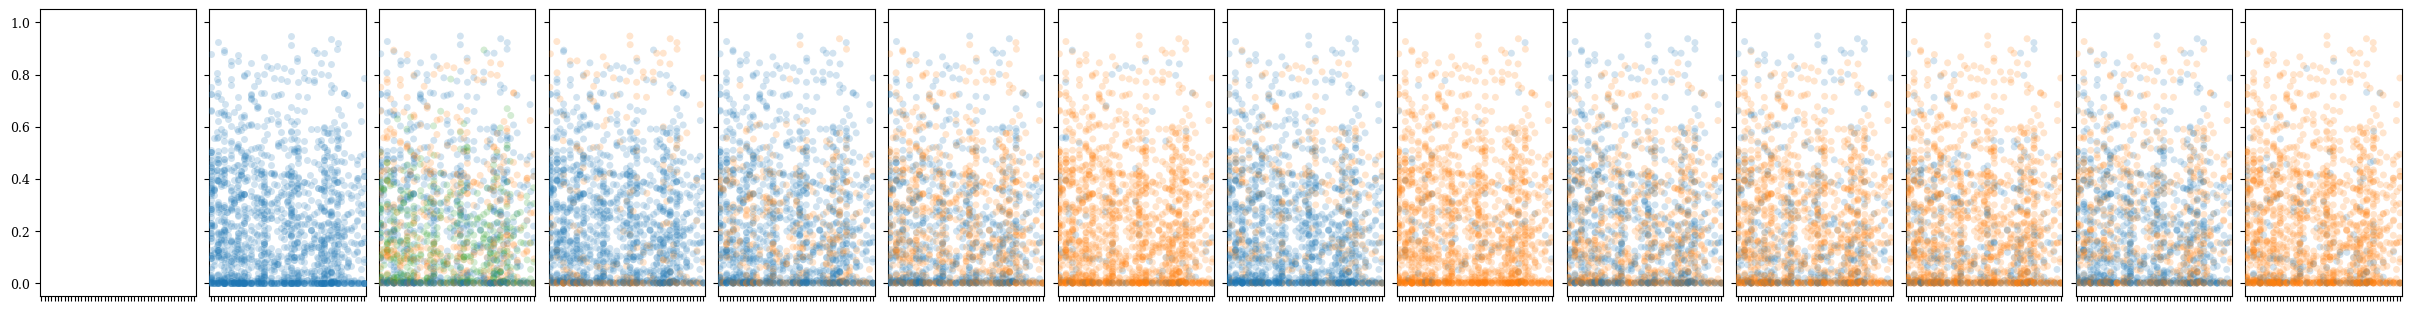

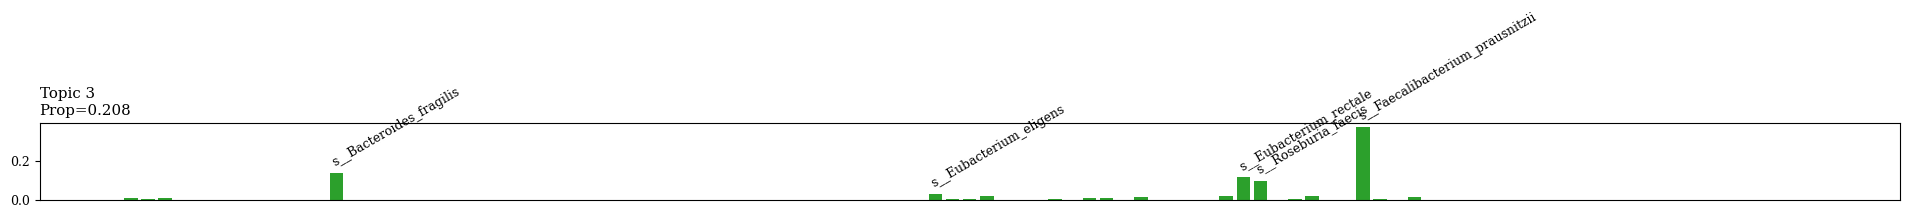

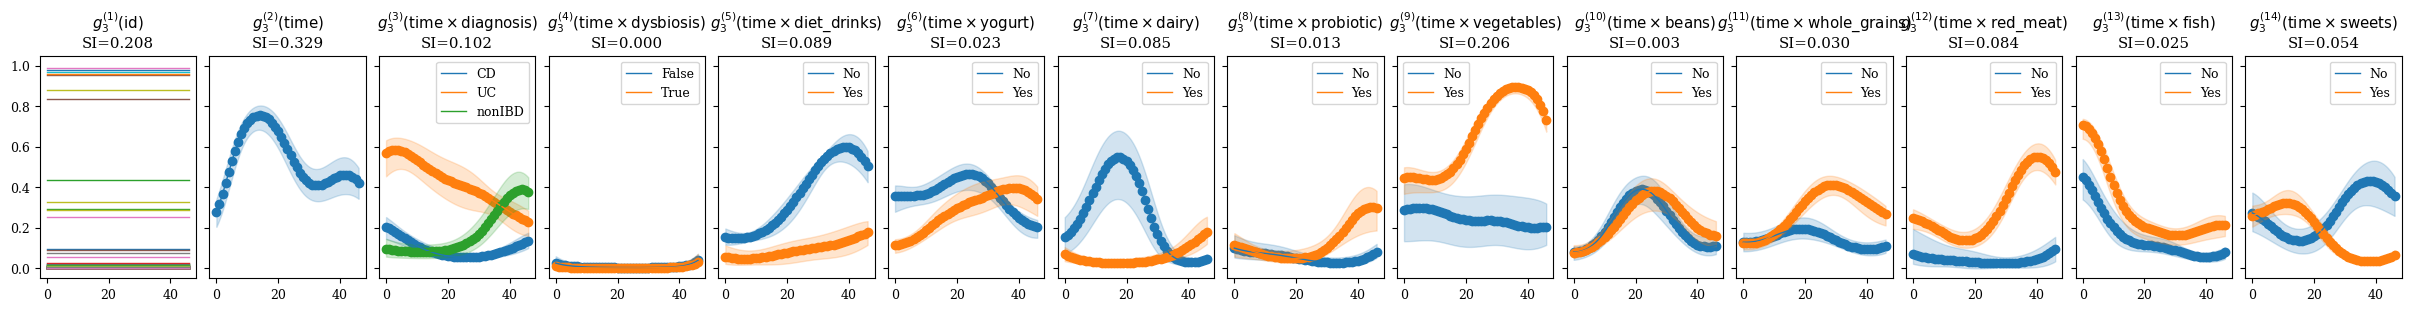

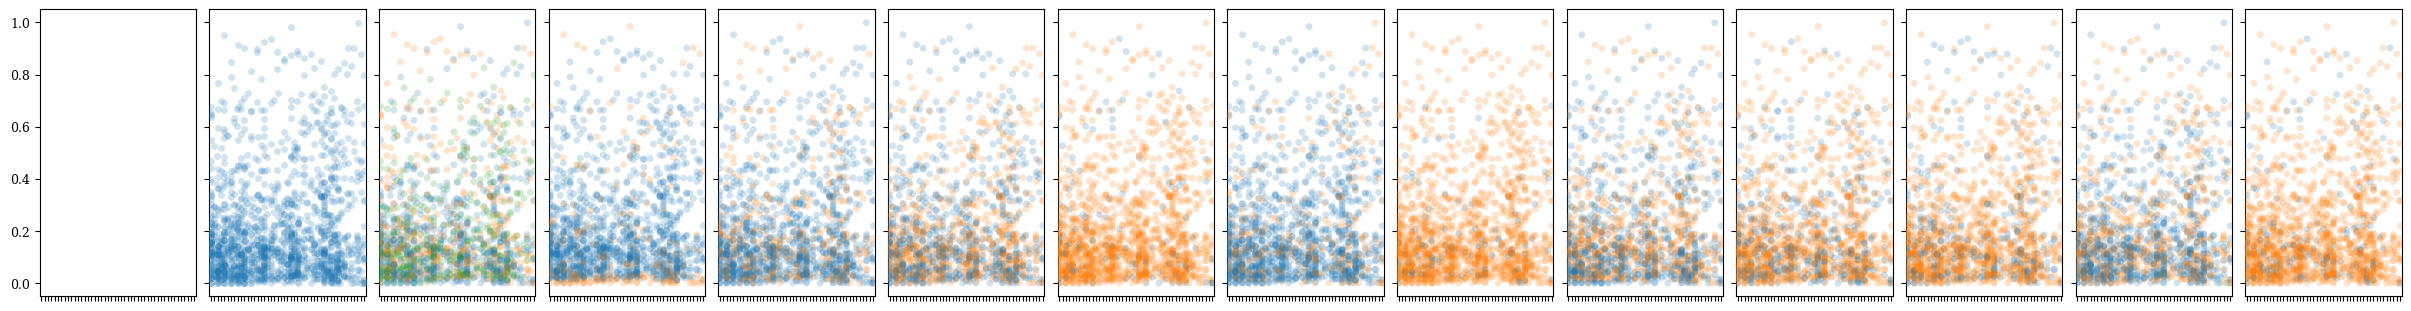

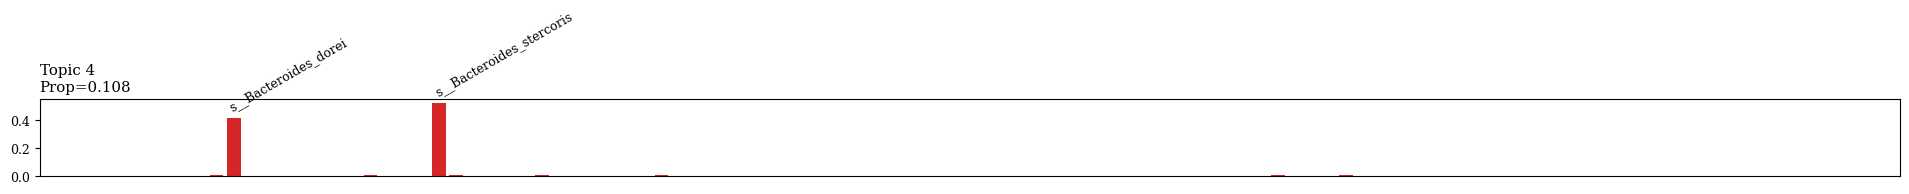

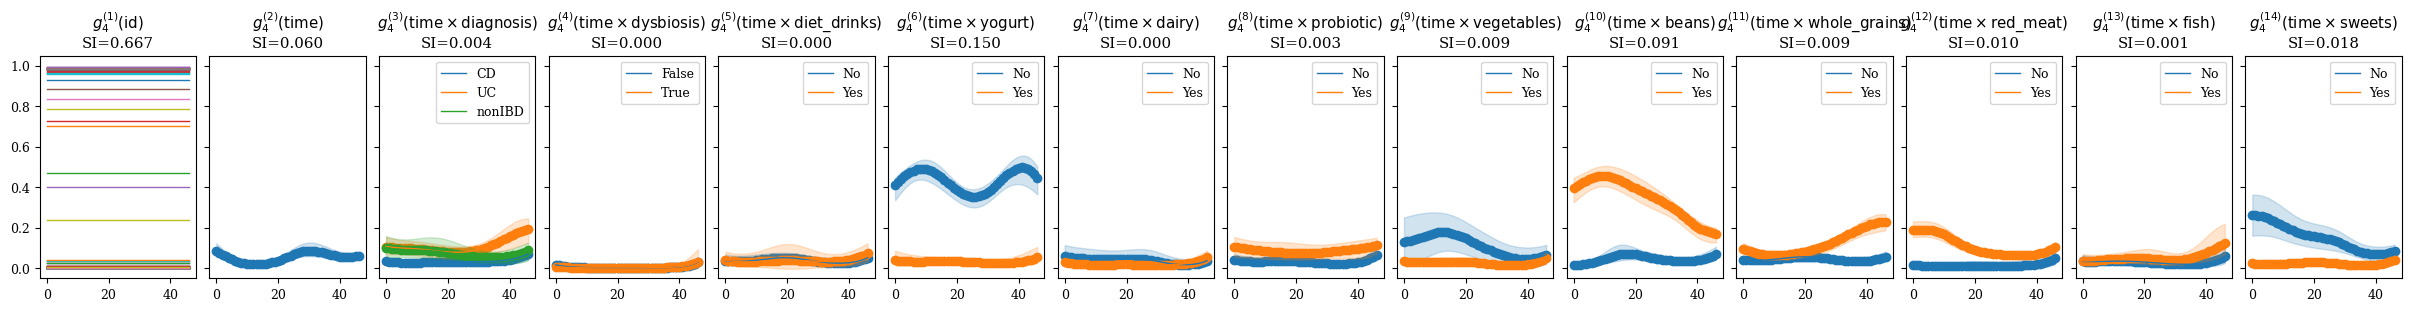

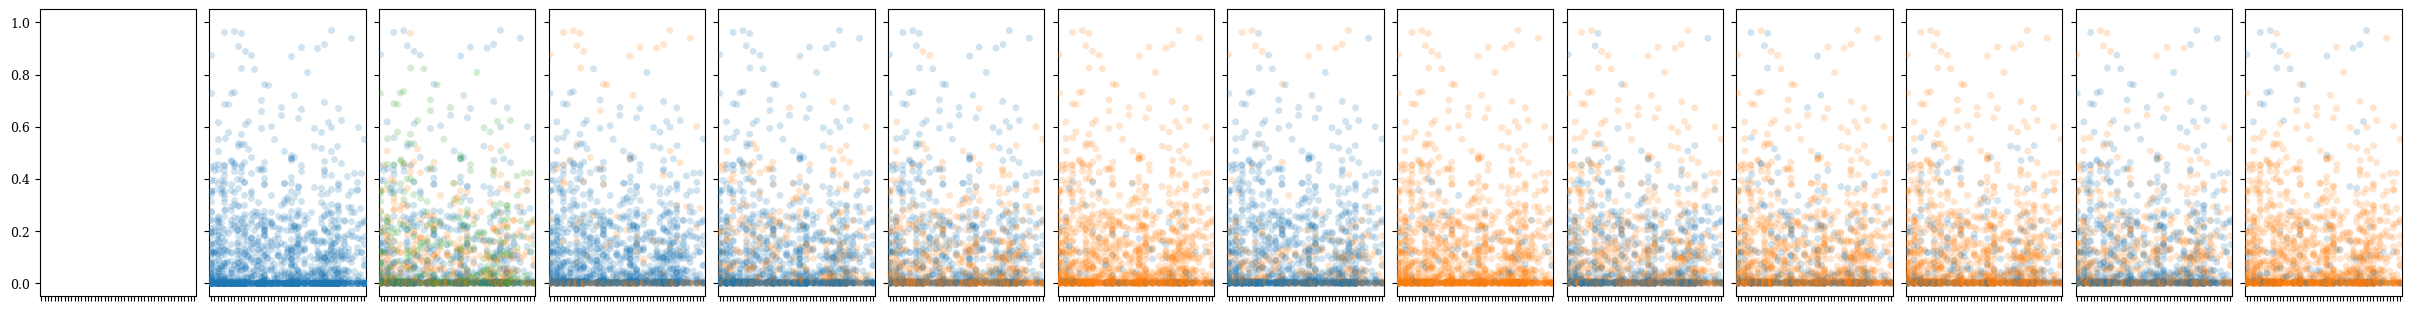

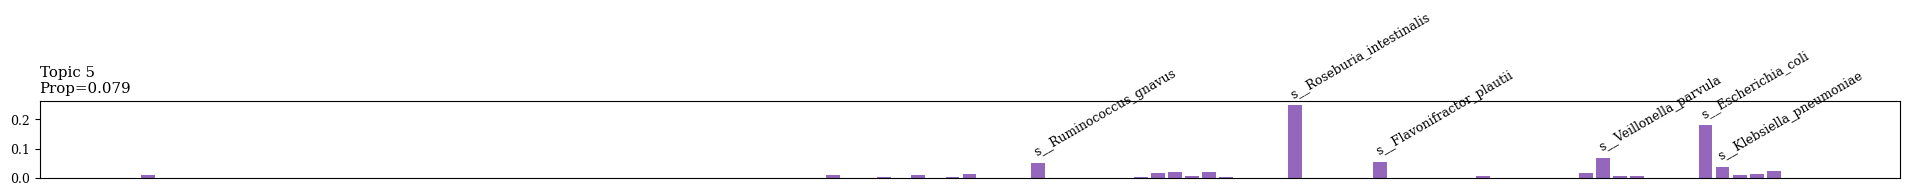

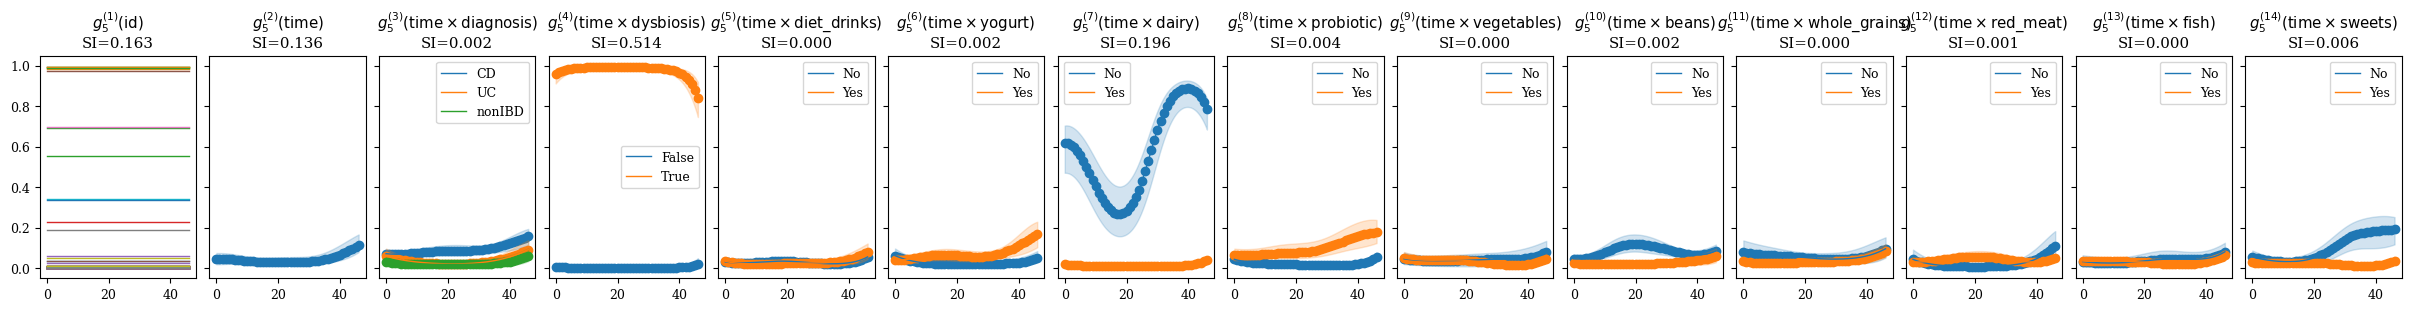

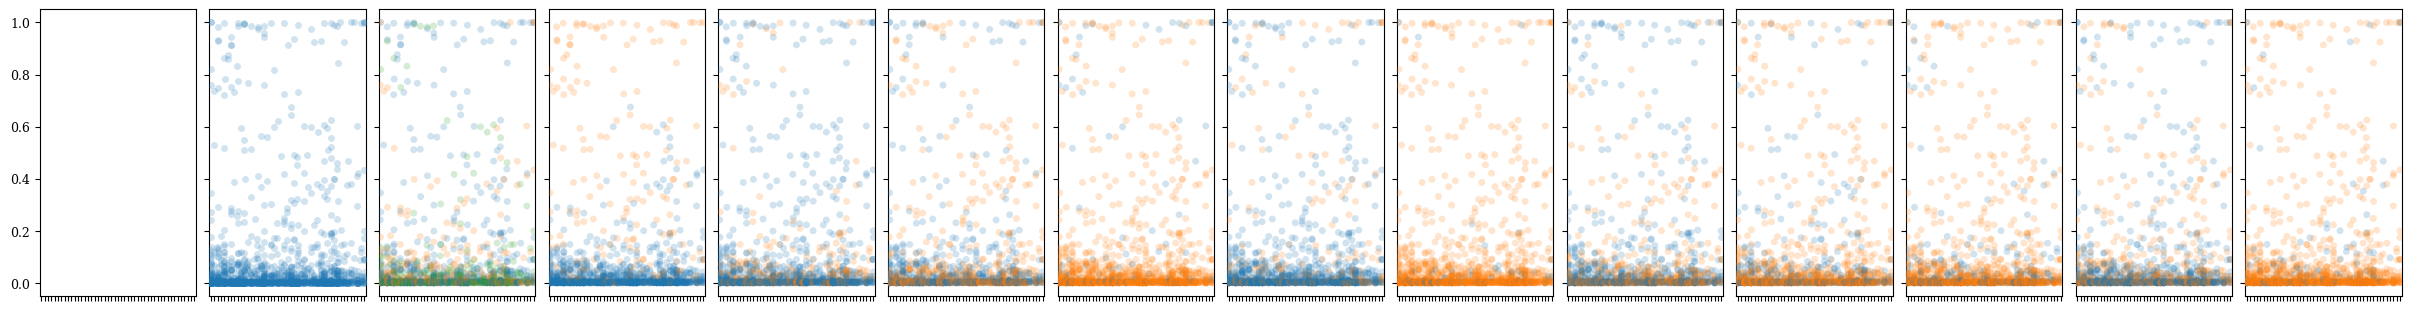

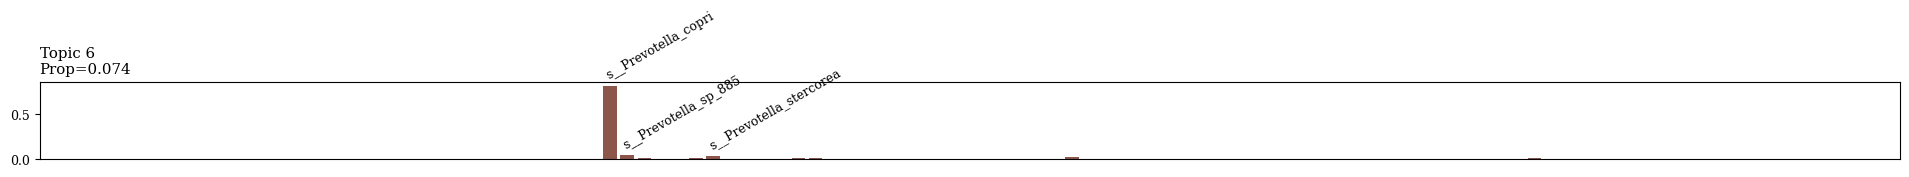

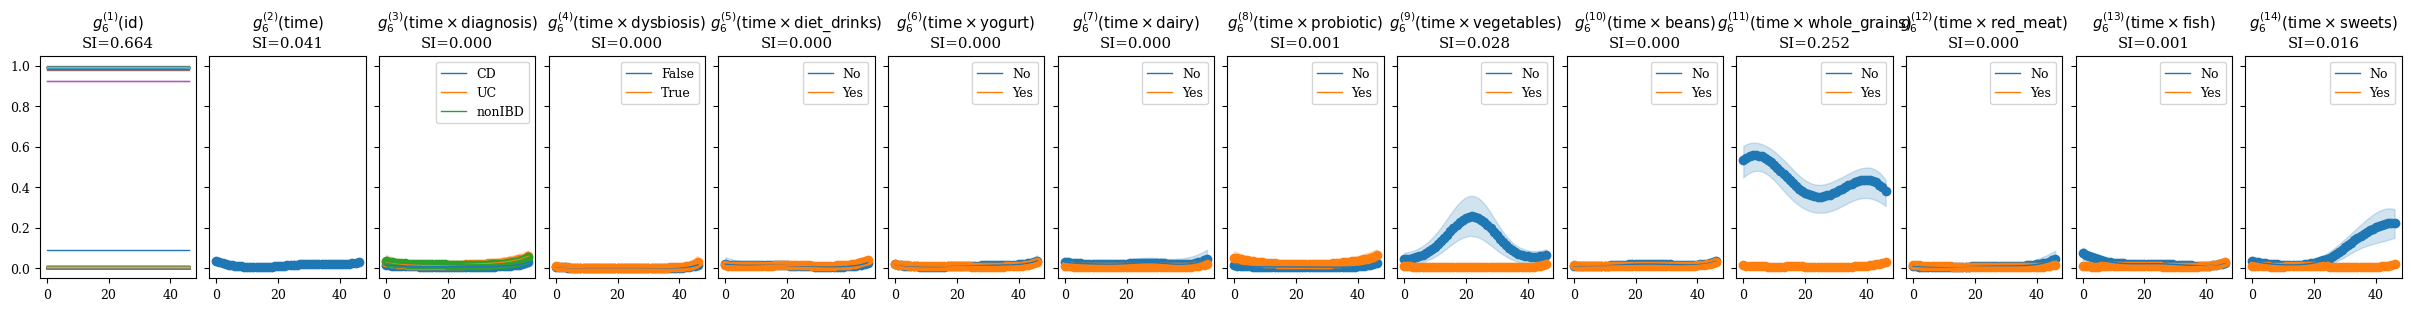

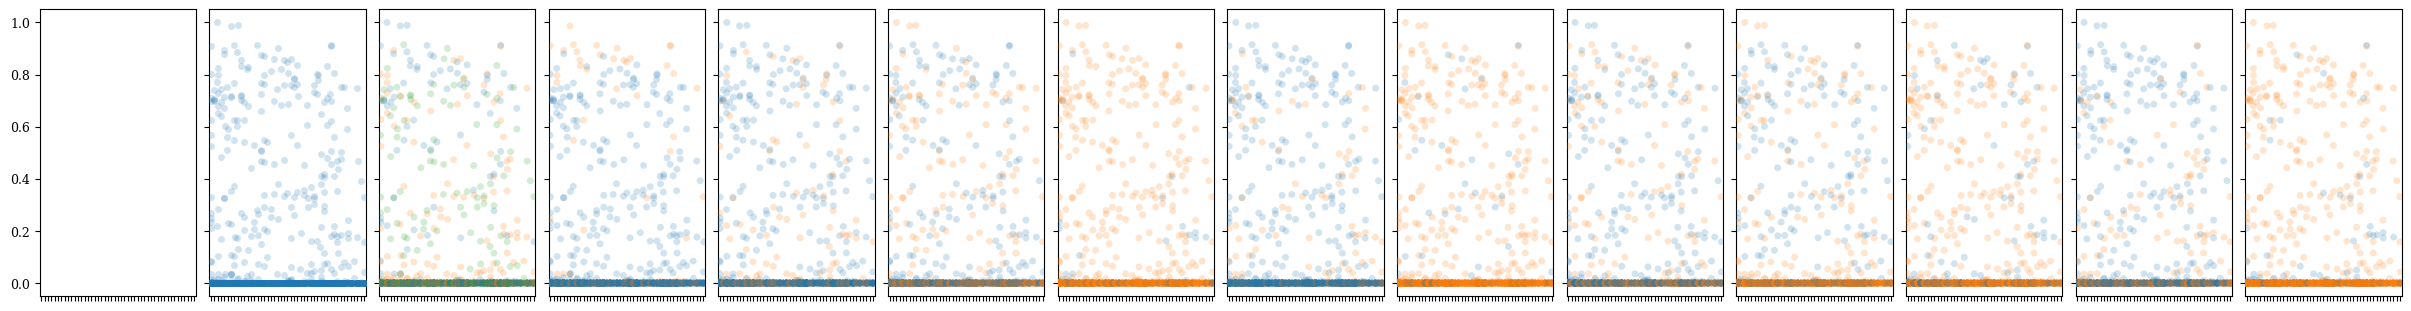

In [9]:
# for each latent dimension: plot the topic, latent functions of additive components, and topic proportions of samples
plt.rcParams.update({"font.size": 9})
l_sorted = np.argsort(np.mean(theta, axis=0))[::-1]
for cnt, l in enumerate(l_sorted):
    fig_1, _ = plot_topic(B, theta, cnt, l, attrs.species)
    fig_2, _ = plot_gp(model, dataset, attrs, cnt, l, sobol_result, plot_softmax=True)
    fig_3, _ = plot_latent(model, attrs, theta, l, plot_softmax=True)